## Following Jenny Su's Hubble photometry, Hubble PSF fitting for SN 1983V

### Filters: F275W, F336W, F438W, F555W, F814W

##### Make sure in correct env

In [2]:
import sys
sys.executable

'/Users/sophiakressy/miniconda3/envs/ori_env/bin/python'

In [3]:

%matplotlib inline

In [4]:
import sys,os,glob
from astropy.io import fits
from astropy.coordinates import SkyCoord
from astropy import units as u
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import (simple_norm,LinearStretch)
plt.rcParams['figure.dpi'] = 200

from stwcs import wcsutil
# import jhat
# from jhat import hst_photclass, st_wcs_align
import space_phot
import shutil
import drizzlepac
import pickle



The following task in the stsci.skypac package can be run with TEAL:
                                    skymatch                                    


**WARNING**: LOCAL JWST PRD VERSION PRDOPSSOC-068 DOESN'T MATCH THE CURRENT ONLINE VERSION PRDOPSSOC-072
Please consider updating pysiaf, e.g. pip install --upgrade pysiaf or conda update pysiaf


Import HST lvl2 (FLC) and lvl3 (DRZ) files -- change directory if needed

In [ ]:
drzfiles = glob.glob('HST/drz_lvl3/*drz.fits')
flcfiles = glob.glob('HST/flc_lvl2/*flc.fits')

In [6]:
drzfiles

['HST/drz_lvl3/F438W_drz.fits',
 'HST/drz_lvl3/F814W_drz.fits',
 'HST/drz_lvl3/F336W_drz.fits',
 'HST/drz_lvl3/F555W_drz.fits',
 'HST/drz_lvl3/F657N_drz.fits',
 'HST/drz_lvl3/F275W_drz.fits']

In [7]:
flcfiles

['HST/flc_lvl2/F657N_if0404y2q_flc.fits',
 'HST/flc_lvl2/F336W_idxr09yuq_flc.fits',
 'HST/flc_lvl2/F555W_idxr09ztq_flc.fits',
 'HST/flc_lvl2/F657N_if0404xyq_flc.fits',
 'HST/flc_lvl2/F555W_idxr09z0q_flc.fits',
 'HST/flc_lvl2/F814W_idxr09z2q_flc.fits',
 'HST/flc_lvl2/F275W_idxr09ywq_flc.fits',
 'HST/flc_lvl2/F657N_if0404xxq_flc.fits',
 'HST/flc_lvl2/F657N_if0404y0q_flc.fits',
 'HST/flc_lvl2/F814W_idxr09yqq_flc.fits',
 'HST/flc_lvl2/F438W_idxr09ysq_flc.fits',
 'HST/flc_lvl2/F275W_idxr09z9q_flc.fits',
 'HST/flc_lvl2/F438W_idxr09ziq_flc.fits',
 'HST/flc_lvl2/F814W_idxr09zfq_flc.fits',
 'HST/flc_lvl2/F275W_idxr09zpq_flc.fits',
 'HST/flc_lvl2/F336W_idxr09zkq_flc.fits',
 'HST/flc_lvl2/F336W_idxr09z7q_flc.fits',
 'HST/flc_lvl2/F555W_idxr09zdq_flc.fits',
 'HST/flc_lvl2/F438W_idxr09z5q_flc.fits']

In [8]:
filter_arr = []
file_arr = []
for flc in flcfiles:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)

    
print(filter_arr)
print(file_arr)

['F657N', 'F336W', 'F555W', 'F657N', 'F555W', 'F814W', 'F275W', 'F657N', 'F657N', 'F814W', 'F438W', 'F275W', 'F438W', 'F814W', 'F275W', 'F336W', 'F336W', 'F555W', 'F438W']
['HST/flc_lvl2/F657N_if0404y2q_flc.fits', 'HST/flc_lvl2/F336W_idxr09yuq_flc.fits', 'HST/flc_lvl2/F555W_idxr09ztq_flc.fits', 'HST/flc_lvl2/F657N_if0404xyq_flc.fits', 'HST/flc_lvl2/F555W_idxr09z0q_flc.fits', 'HST/flc_lvl2/F814W_idxr09z2q_flc.fits', 'HST/flc_lvl2/F275W_idxr09ywq_flc.fits', 'HST/flc_lvl2/F657N_if0404xxq_flc.fits', 'HST/flc_lvl2/F657N_if0404y0q_flc.fits', 'HST/flc_lvl2/F814W_idxr09yqq_flc.fits', 'HST/flc_lvl2/F438W_idxr09ysq_flc.fits', 'HST/flc_lvl2/F275W_idxr09z9q_flc.fits', 'HST/flc_lvl2/F438W_idxr09ziq_flc.fits', 'HST/flc_lvl2/F814W_idxr09zfq_flc.fits', 'HST/flc_lvl2/F275W_idxr09zpq_flc.fits', 'HST/flc_lvl2/F336W_idxr09zkq_flc.fits', 'HST/flc_lvl2/F336W_idxr09z7q_flc.fits', 'HST/flc_lvl2/F555W_idxr09zdq_flc.fits', 'HST/flc_lvl2/F438W_idxr09z5q_flc.fits']


In [9]:
filter_arr

['F657N',
 'F336W',
 'F555W',
 'F657N',
 'F555W',
 'F814W',
 'F275W',
 'F657N',
 'F657N',
 'F814W',
 'F438W',
 'F275W',
 'F438W',
 'F814W',
 'F275W',
 'F336W',
 'F336W',
 'F555W',
 'F438W']

Assign SN location for 1983V

In [10]:
sn_location = SkyCoord('3:33:31.6159','-36:08:55.222',unit=(u.hourangle,u.deg))

print(sn_location)

<SkyCoord (ICRS): (ra, dec) in deg
    (53.38173292, -36.14867278)>


## F275W

In [11]:
indices = [i for i, x in enumerate(filter_arr) if x == 'F275W']
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_flcs = files[tmp]
input_flcs = input_flcs.tolist()
input_flcs

['HST/flc_lvl2/F275W_idxr09ywq_flc.fits',
 'HST/flc_lvl2/F275W_idxr09z9q_flc.fits',
 'HST/flc_lvl2/F275W_idxr09zpq_flc.fits']

In [12]:
hst_flc_obs = space_phot.observation2(input_flcs)
hst_drz_obs = space_phot.observation3('HST/drz_lvl3/F275W_drz.fits')
# hst_drz_obs = space_phot.observation3('./my_ad/f555w_17gax_{}_jhat_drc.fits'.format(year))


Cannot create flux_units from header...assuming electrons/s


/Users/sophiakressy/miniconda3/envs/ori_env/lib/python3.11/site-packages/space_phot/wfc3_photometry/psfs/PSFSTD_WFC3UV_F275W.fits
Using PSF file PSFSTD_WFC3UV_F275W.fits
Setting up logfile :  astrodrizzle.log
AstroDrizzle log file: astrodrizzle.log
AstroDrizzle Version 3.10.0 started at: 11:06:37.00 (08/12/2025)

==== Processing Step  Initialization  started at  11:06:37.003 (08/12/2025)

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 53.39177229877254 -36.13944097663628 
CRPIX : 2065.5000000000173 1198.50000000001 
CD1_1 CD1_2  : 3.5844853988302498e-06 1.040546600712561e-05 
CD2_1 CD2_2  : 1.040546600712561e-05 -3.5844853988302498e-06 
NAXIS : 4132  2398
********************************************************************************
*
*  Estimated memory usage:  up to 177 Mb.
*  Output image size:       4132 X 2398 pixels. 
*  Output image file:       ~ 113 Mb. 
*  Cores available:         1
*
***************************************************************

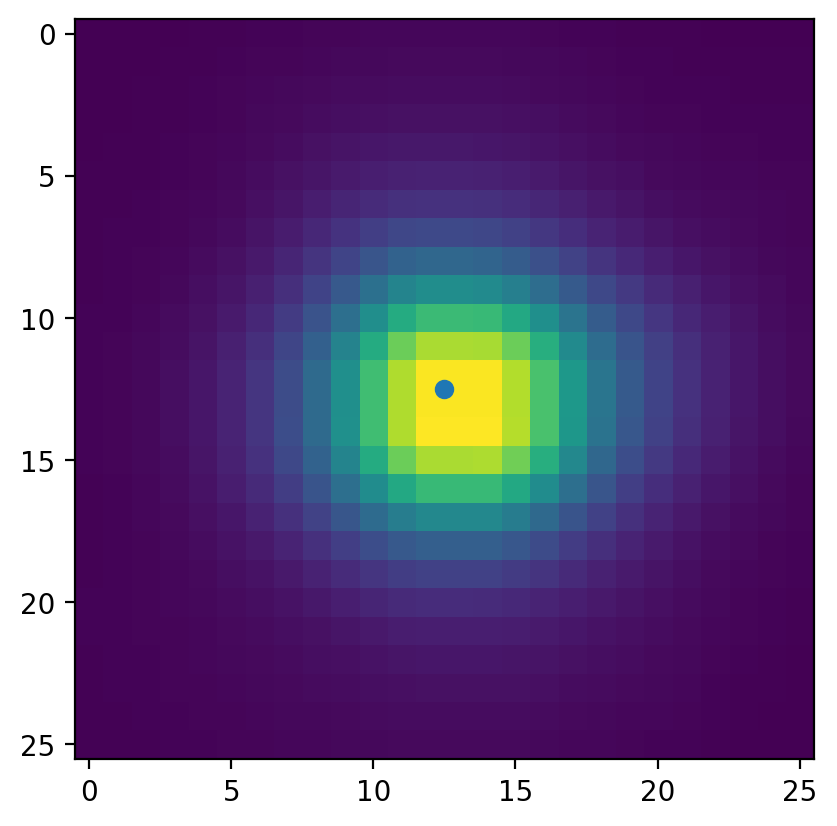

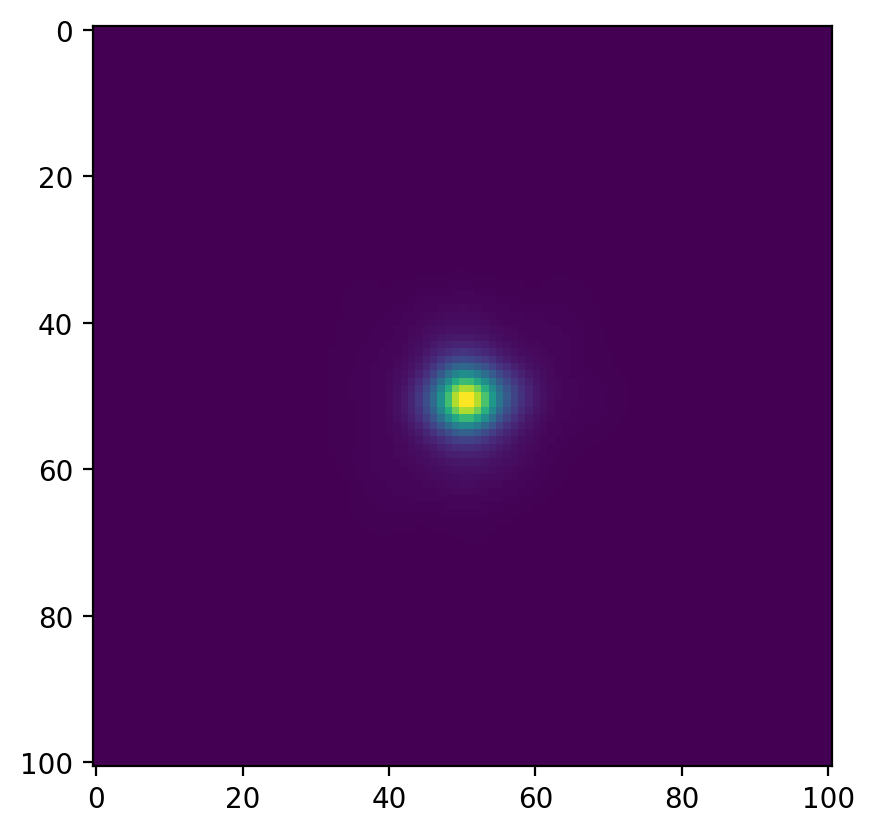

In [13]:
#psf_drz = pickle.load(open('psf_f555w_17gax.pkl','rb')) 
psf_drz = space_phot.get_hst3_psf(hst_flc_obs,hst_drz_obs,sn_location)#,num_psfs=4)
plt.imshow(psf_drz.data)
plt.show()

iter: 1553 | +100 | bound: 142 | nc: 1 | ncall: 22269 | eff(%):  7.456 | loglstar:   -inf < -0.013 <    inf | logz: -13.195 +/-  0.349 | dlogz:  0.001 >  0.109                                       

[1.97537555 1.27152426 1.22246319 0.02597192]
0.34652321555320015
[0.68451349 0.44061267 0.42361187 0.00899987]
Finished PSF psf_photometry with median residuals of -981.18%


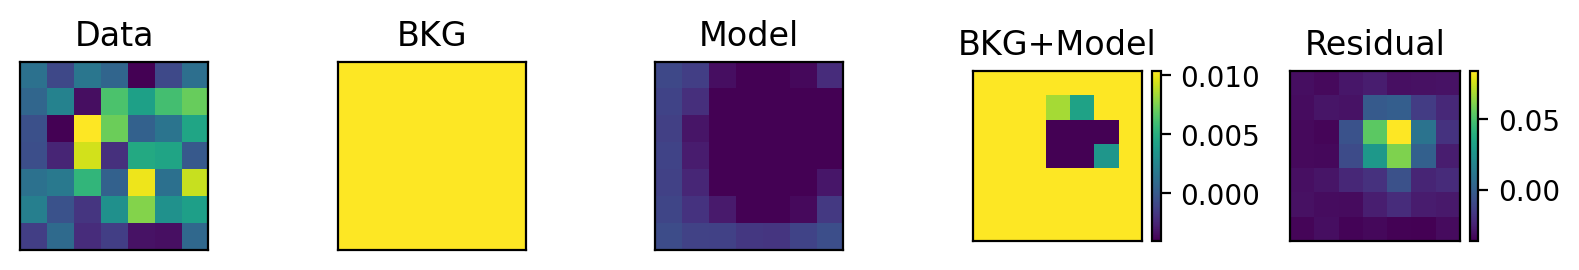

In [14]:
hst_drz_obs.psf_photometry(psf_drz,sn_location,bounds={'flux':[-30000,30000],
                        'centroid':[-2,2],
                        'bkg':[0,1]},
                        fit_width=7, 
                        background = 0.0, #(DS9), # 0.1 for 2023, #0.2 for 2019
                        fit_bkg=True,
                        fit_centroid=True, 
                        fit_flux=True,psf_method='nest')

hst_drz_obs.plot_psf_fit()
plt.show()

In [15]:
# hst_drz_obs.plot_psf_posterior()
# plt.show()

# print(hst_drz_obs.psf_result.phot_cal_table)
# #sys.exit()

In [16]:
# hst_drz_obs.psf_result.phot_cal_table

In [17]:
hst_drz_obs.psf_result.phot_cal_table['mag','magerr']

mag,magerr
float64,float64
nan,-2.4183793175524038


In [18]:
hst_drz_obs.upper_limit(nsigma=5)

21.663632498854987

In [21]:
flux_jy = 10**(-0.4 * (hst_drz_obs.upper_limit(nsigma=5) + 48.6)) * 1e23
print(flux_jy)
print(np.log10(flux_jy))

7.844170059002863e-06
-5.1054529995419955


## F336W

In [28]:
indices = [i for i, x in enumerate(filter_arr) if x == 'F336W']
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_flcs = files[tmp]
input_flcs = input_flcs.tolist()
input_flcs

['HST/flc_lvl2/F336W_idxr09yuq_flc.fits',
 'HST/flc_lvl2/F336W_idxr09zkq_flc.fits',
 'HST/flc_lvl2/F336W_idxr09z7q_flc.fits']

In [29]:
hst_flc_obs = space_phot.observation2(input_flcs)
hst_drz_obs = space_phot.observation3('HST/drz_lvl3/F336W_drz.fits')
# hst_drz_obs = space_phot.observation3('./my_ad/f555w_17gax_{}_jhat_drc.fits'.format(year))

Cannot create flux_units from header...assuming electrons/s


/Users/sophiakressy/miniconda3/envs/ori_env/lib/python3.11/site-packages/space_phot/wfc3_photometry/psfs/PSFSTD_WFC3UV_F336W.fits
Using PSF file PSFSTD_WFC3UV_F336W.fits
Setting up logfile :  astrodrizzle.log
AstroDrizzle log file: astrodrizzle.log
AstroDrizzle Version 3.10.0 started at: 15:28:24.786 (18/11/2025)

==== Processing Step  Initialization  started at  15:28:24.786 (18/11/2025)

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 53.39177733243727 -36.1394452174207 
CRPIX : 2065.500000000006 1198.0000000000034 
CD1_1 CD1_2  : 3.584485398786038e-06 1.0405466007140904e-05 
CD2_1 CD2_2  : 1.0405466007140904e-05 -3.584485398786038e-06 
NAXIS : 4132  2397
********************************************************************************
*
*  Estimated memory usage:  up to 177 Mb.
*  Output image size:       4132 X 2397 pixels. 
*  Output image file:       ~ 113 Mb. 
*  Cores available:         1
*
**************************************************************

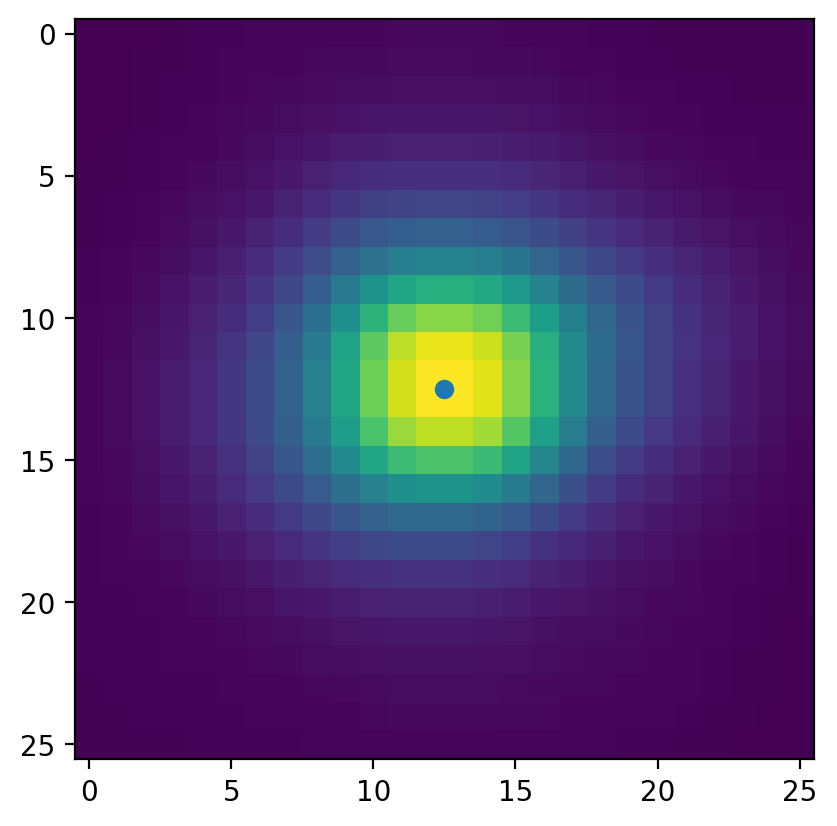

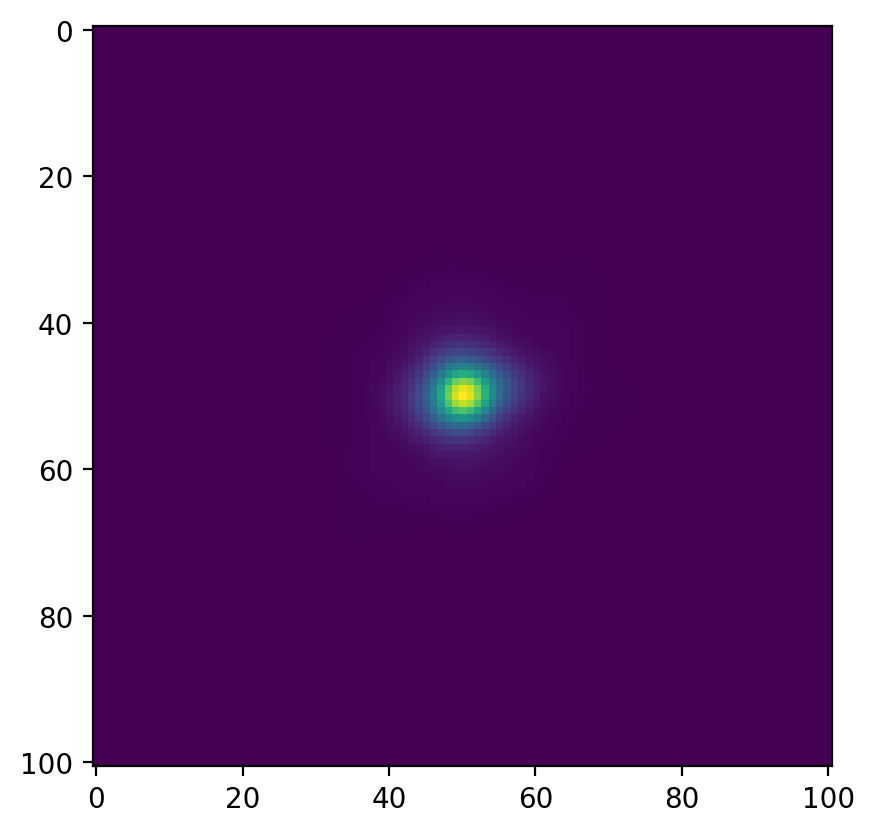

In [30]:
#psf_drz = pickle.load(open('psf_f555w_17gax.pkl','rb')) 
psf_drz = space_phot.get_hst3_psf(hst_flc_obs,hst_drz_obs,sn_location)#,num_psfs=4)
plt.imshow(psf_drz.data)
plt.show()

iter: 1197 | +100 | bound: 48 | nc: 1 | ncall: 8963 | eff(%): 14.634 | loglstar:   -inf < -0.002 <    inf | logz: -9.641 +/-  0.299 | dlogz:  0.001 >  0.109                                          

[1.38187619 1.31506094 1.23926301]
0.34273596287114916
[0.47361867 0.45071868 0.42474   ]
Finished PSF psf_photometry with median residuals of 118.35%


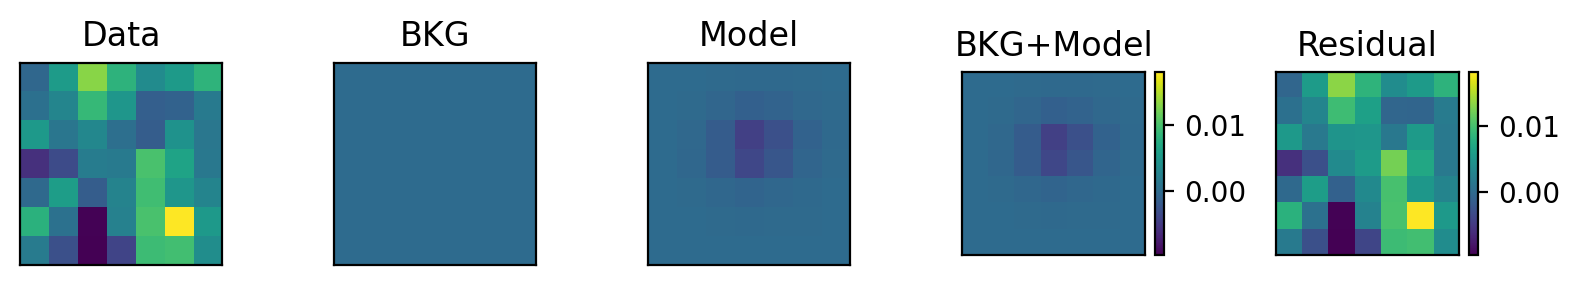

In [33]:
hst_drz_obs.psf_photometry(psf_drz,sn_location,bounds={'flux':[-30000,30000],
                        'centroid':[-2,2],
                        'bkg':[0,10]},
                        fit_width=7, 
                        background = 0.0, #(DS9), # 0.1 for 2023, #0.2 for 2019
                        # fit_bkg=True,
                        fit_centroid=True, 
                        fit_flux=True,psf_method='nest')

hst_drz_obs.plot_psf_fit()
plt.show()

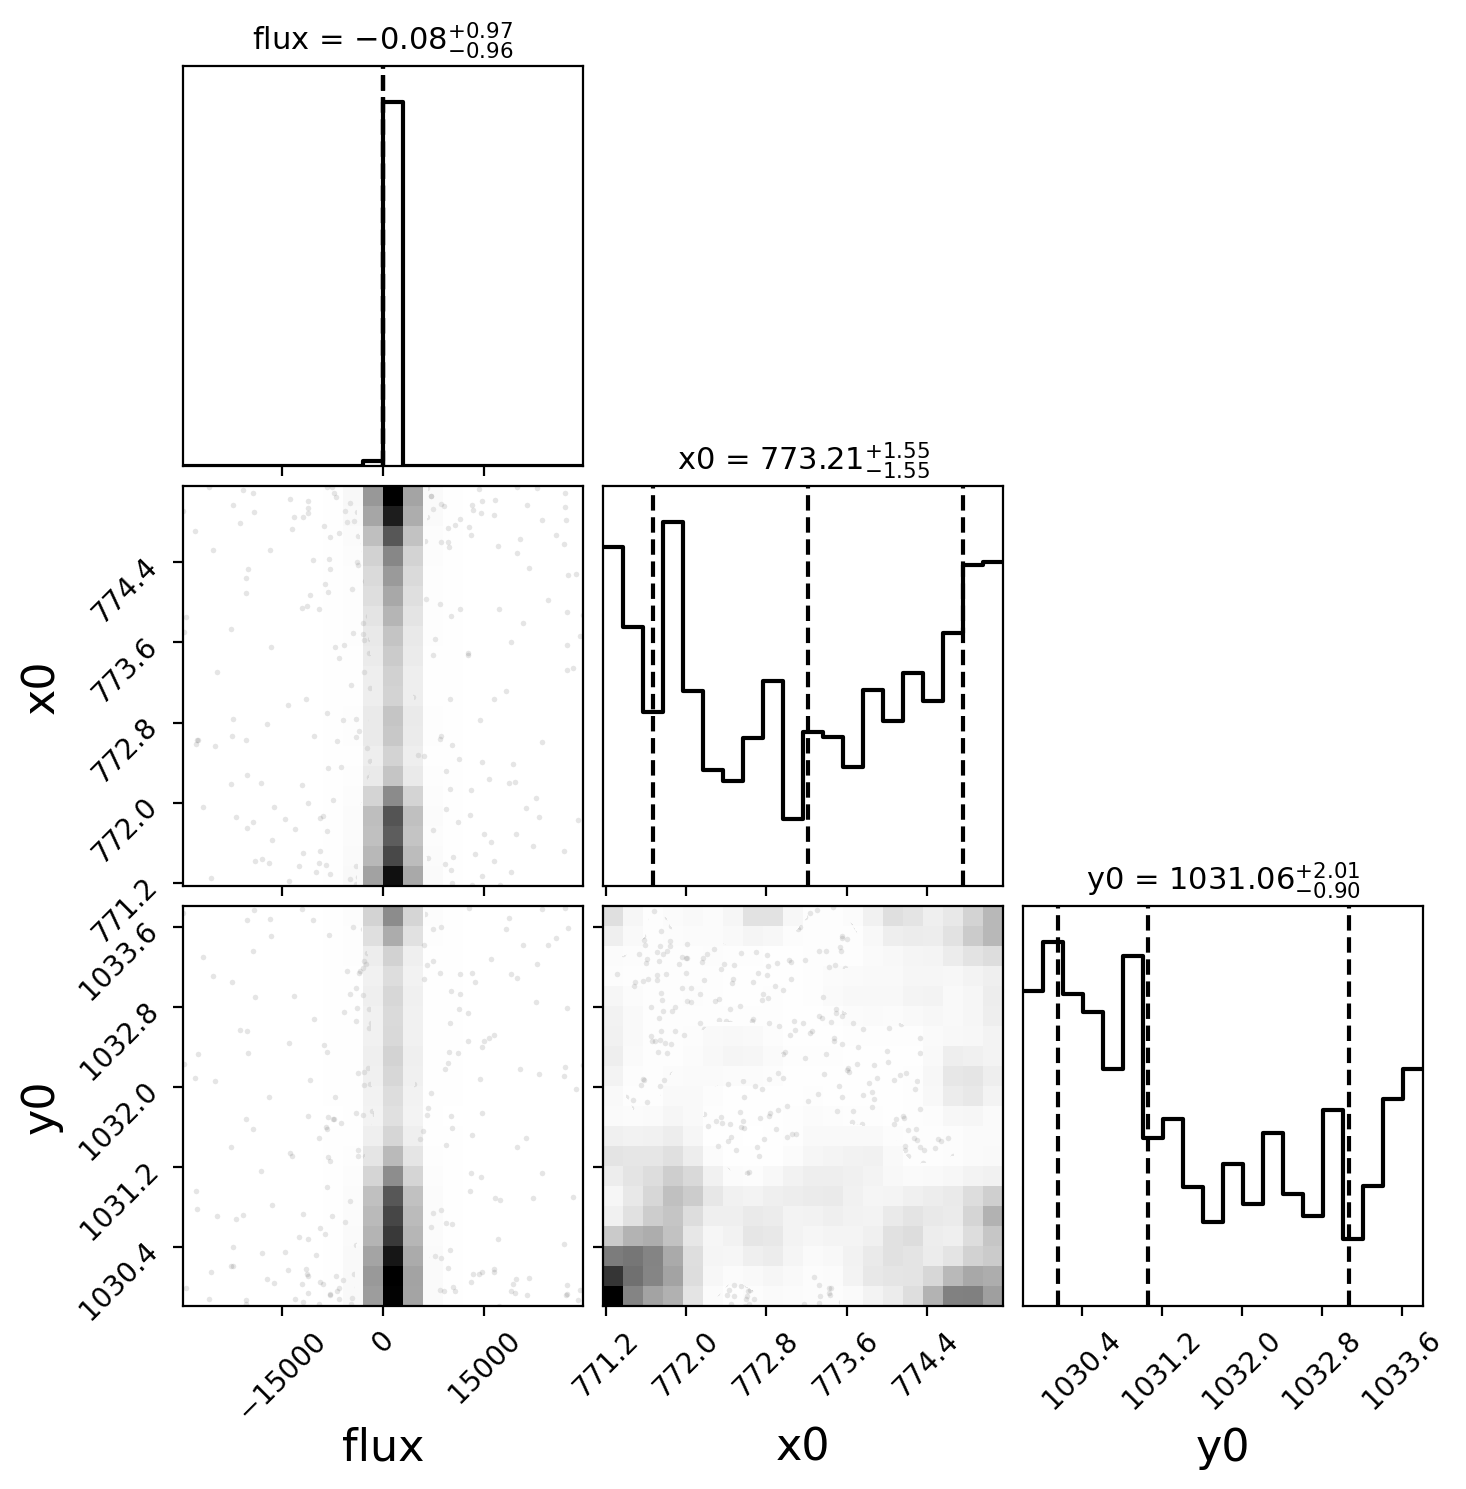

In [34]:
hst_drz_obs.plot_psf_posterior()
plt.show()

In [35]:
print(hst_drz_obs.psf_result.phot_cal_table)
#sys.exit()

        ra                ra_err         ... zpsys      exp      
----------------- ---------------------- ... ----- --------------
53.38173164296802 2.2449732675511314e-05 ...    ab F336W_drz.fits


In [36]:
hst_drz_obs.psf_result.phot_cal_table

ra,ra_err,dec,dec_err,x,x_err,y,y_err,mjd,flux,fluxerr,filter,zp,mag,magerr,zpsys,exp
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str5,float64,float64,float64,str2,str14
53.38173164296802,2.2449732675511314e-05,-36.14867631642316,8.176916658442224e-06,773.1808730359686,1.3150609399925304,1031.4785256827806,1.2392630088497965,58684.87732554,-0.0348400393351209,1.3818761909910149,F336W,24.687566638735067,nan,-43.074507723170875,ab,F336W_drz.fits


In [37]:
hst_drz_obs.psf_result.phot_cal_table['mag','magerr']

mag,magerr
float64,float64
nan,-43.074507723170875


In [38]:
hst_drz_obs.upper_limit(nsigma=5)

22.588968792329382

## F438W

In [39]:
indices = [i for i, x in enumerate(filter_arr) if x == 'F438W']
filters = np.array(filter_arr)
files = np.array(file_arr)

In [40]:
tmp = np.array(indices)
filters[tmp]
input_flcs = files[tmp]
input_flcs = input_flcs.tolist()
input_flcs

['HST/flc_lvl2/F438W_idxr09ysq_flc.fits',
 'HST/flc_lvl2/F438W_idxr09ziq_flc.fits',
 'HST/flc_lvl2/F438W_idxr09z5q_flc.fits']

In [41]:
hst_flc_obs = space_phot.observation2(input_flcs)
hst_drz_obs = space_phot.observation3('HST/drz_lvl3/F438W_drz.fits')
# hst_drz_obs = space_phot.observation3('./my_ad/f555w_17gax_{}_jhat_drc.fits'.format(year))

Cannot create flux_units from header...assuming electrons/s


/Users/sophiakressy/miniconda3/envs/ori_env/lib/python3.11/site-packages/space_phot/wfc3_photometry/psfs/PSFSTD_WFC3UV_F438W.fits
Using PSF file PSFSTD_WFC3UV_F438W.fits
Setting up logfile :  astrodrizzle.log
AstroDrizzle log file: astrodrizzle.log
AstroDrizzle Version 3.10.0 started at: 15:29:25.431 (18/11/2025)

==== Processing Step  Initialization  started at  15:29:25.4 (18/11/2025)

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 53.39177017482697 -36.139449538809906 
CRPIX : 2065.000000000016 1198.0000000000093 
CD1_1 CD1_2  : 3.5844853989112714e-06 1.0405466007097707e-05 
CD2_1 CD2_2  : 1.0405466007097707e-05 -3.5844853989112714e-06 
NAXIS : 4131  2397
********************************************************************************
*
*  Estimated memory usage:  up to 177 Mb.
*  Output image size:       4131 X 2397 pixels. 
*  Output image file:       ~ 113 Mb. 
*  Cores available:         1
*
************************************************************

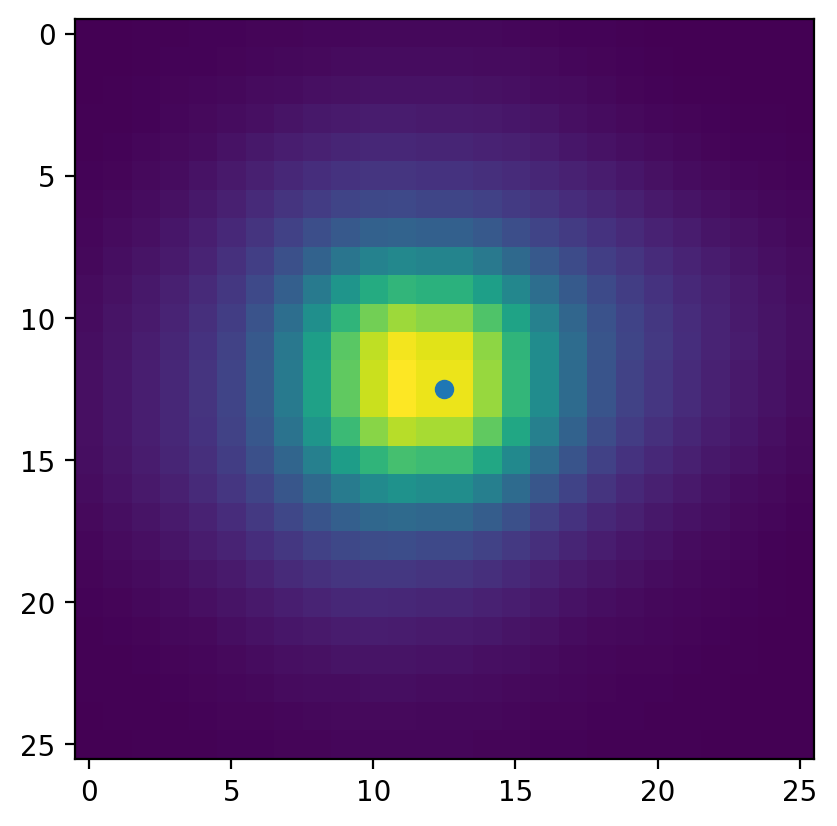

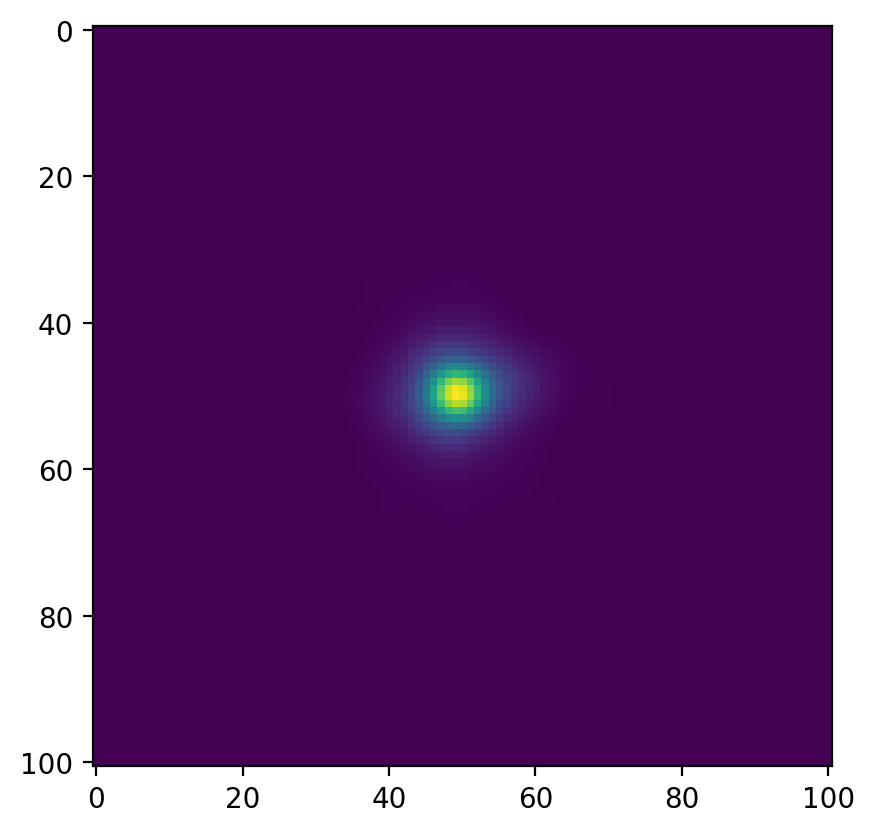

In [42]:
#psf_drz = pickle.load(open('psf_f555w_17gax.pkl','rb')) 
psf_drz = space_phot.get_hst3_psf(hst_flc_obs,hst_drz_obs,sn_location)#,num_psfs=4)
plt.imshow(psf_drz.data)
plt.show()

iter: 1692 | +100 | bound: 149 | nc: 1 | ncall: 21642 | eff(%):  8.319 | loglstar:   -inf < -0.006 <    inf | logz: -14.574 +/-  0.368 | dlogz:  0.001 >  0.109                                       

[2.5657386  1.28256806 1.28330736 0.03067493]
0.34652321555320015
[0.88908799 0.44443961 0.44469579 0.01062958]
Finished PSF psf_photometry with median residuals of 570.23%


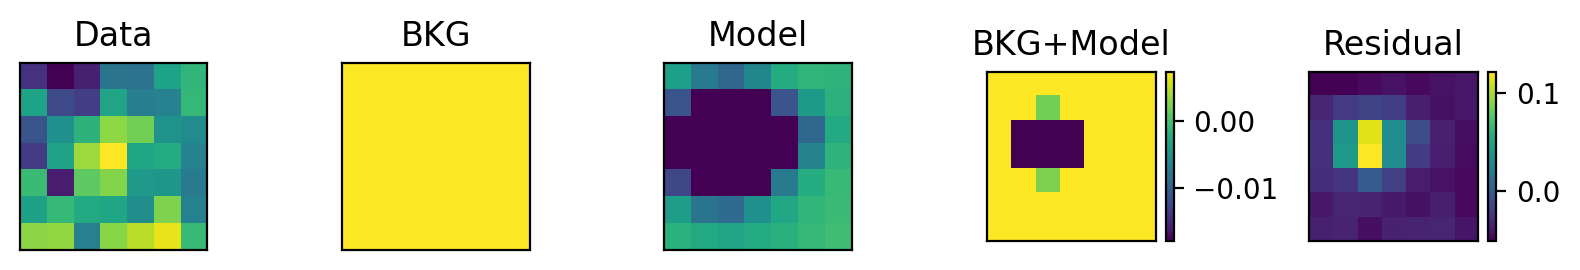

In [48]:
hst_drz_obs.psf_photometry(psf_drz,sn_location,bounds={'flux':[-30000,30000],
                        'centroid':[-2,2],
                        'bkg':[0,10]},
                        fit_width=7, 
                        background = 0.0, #(DS9), # 0.1 for 2023, #0.2 for 2019
                        fit_bkg=True,
                        fit_centroid=True, 
                        fit_flux=True,psf_method='nest')
hst_drz_obs.plot_psf_fit()
plt.show()

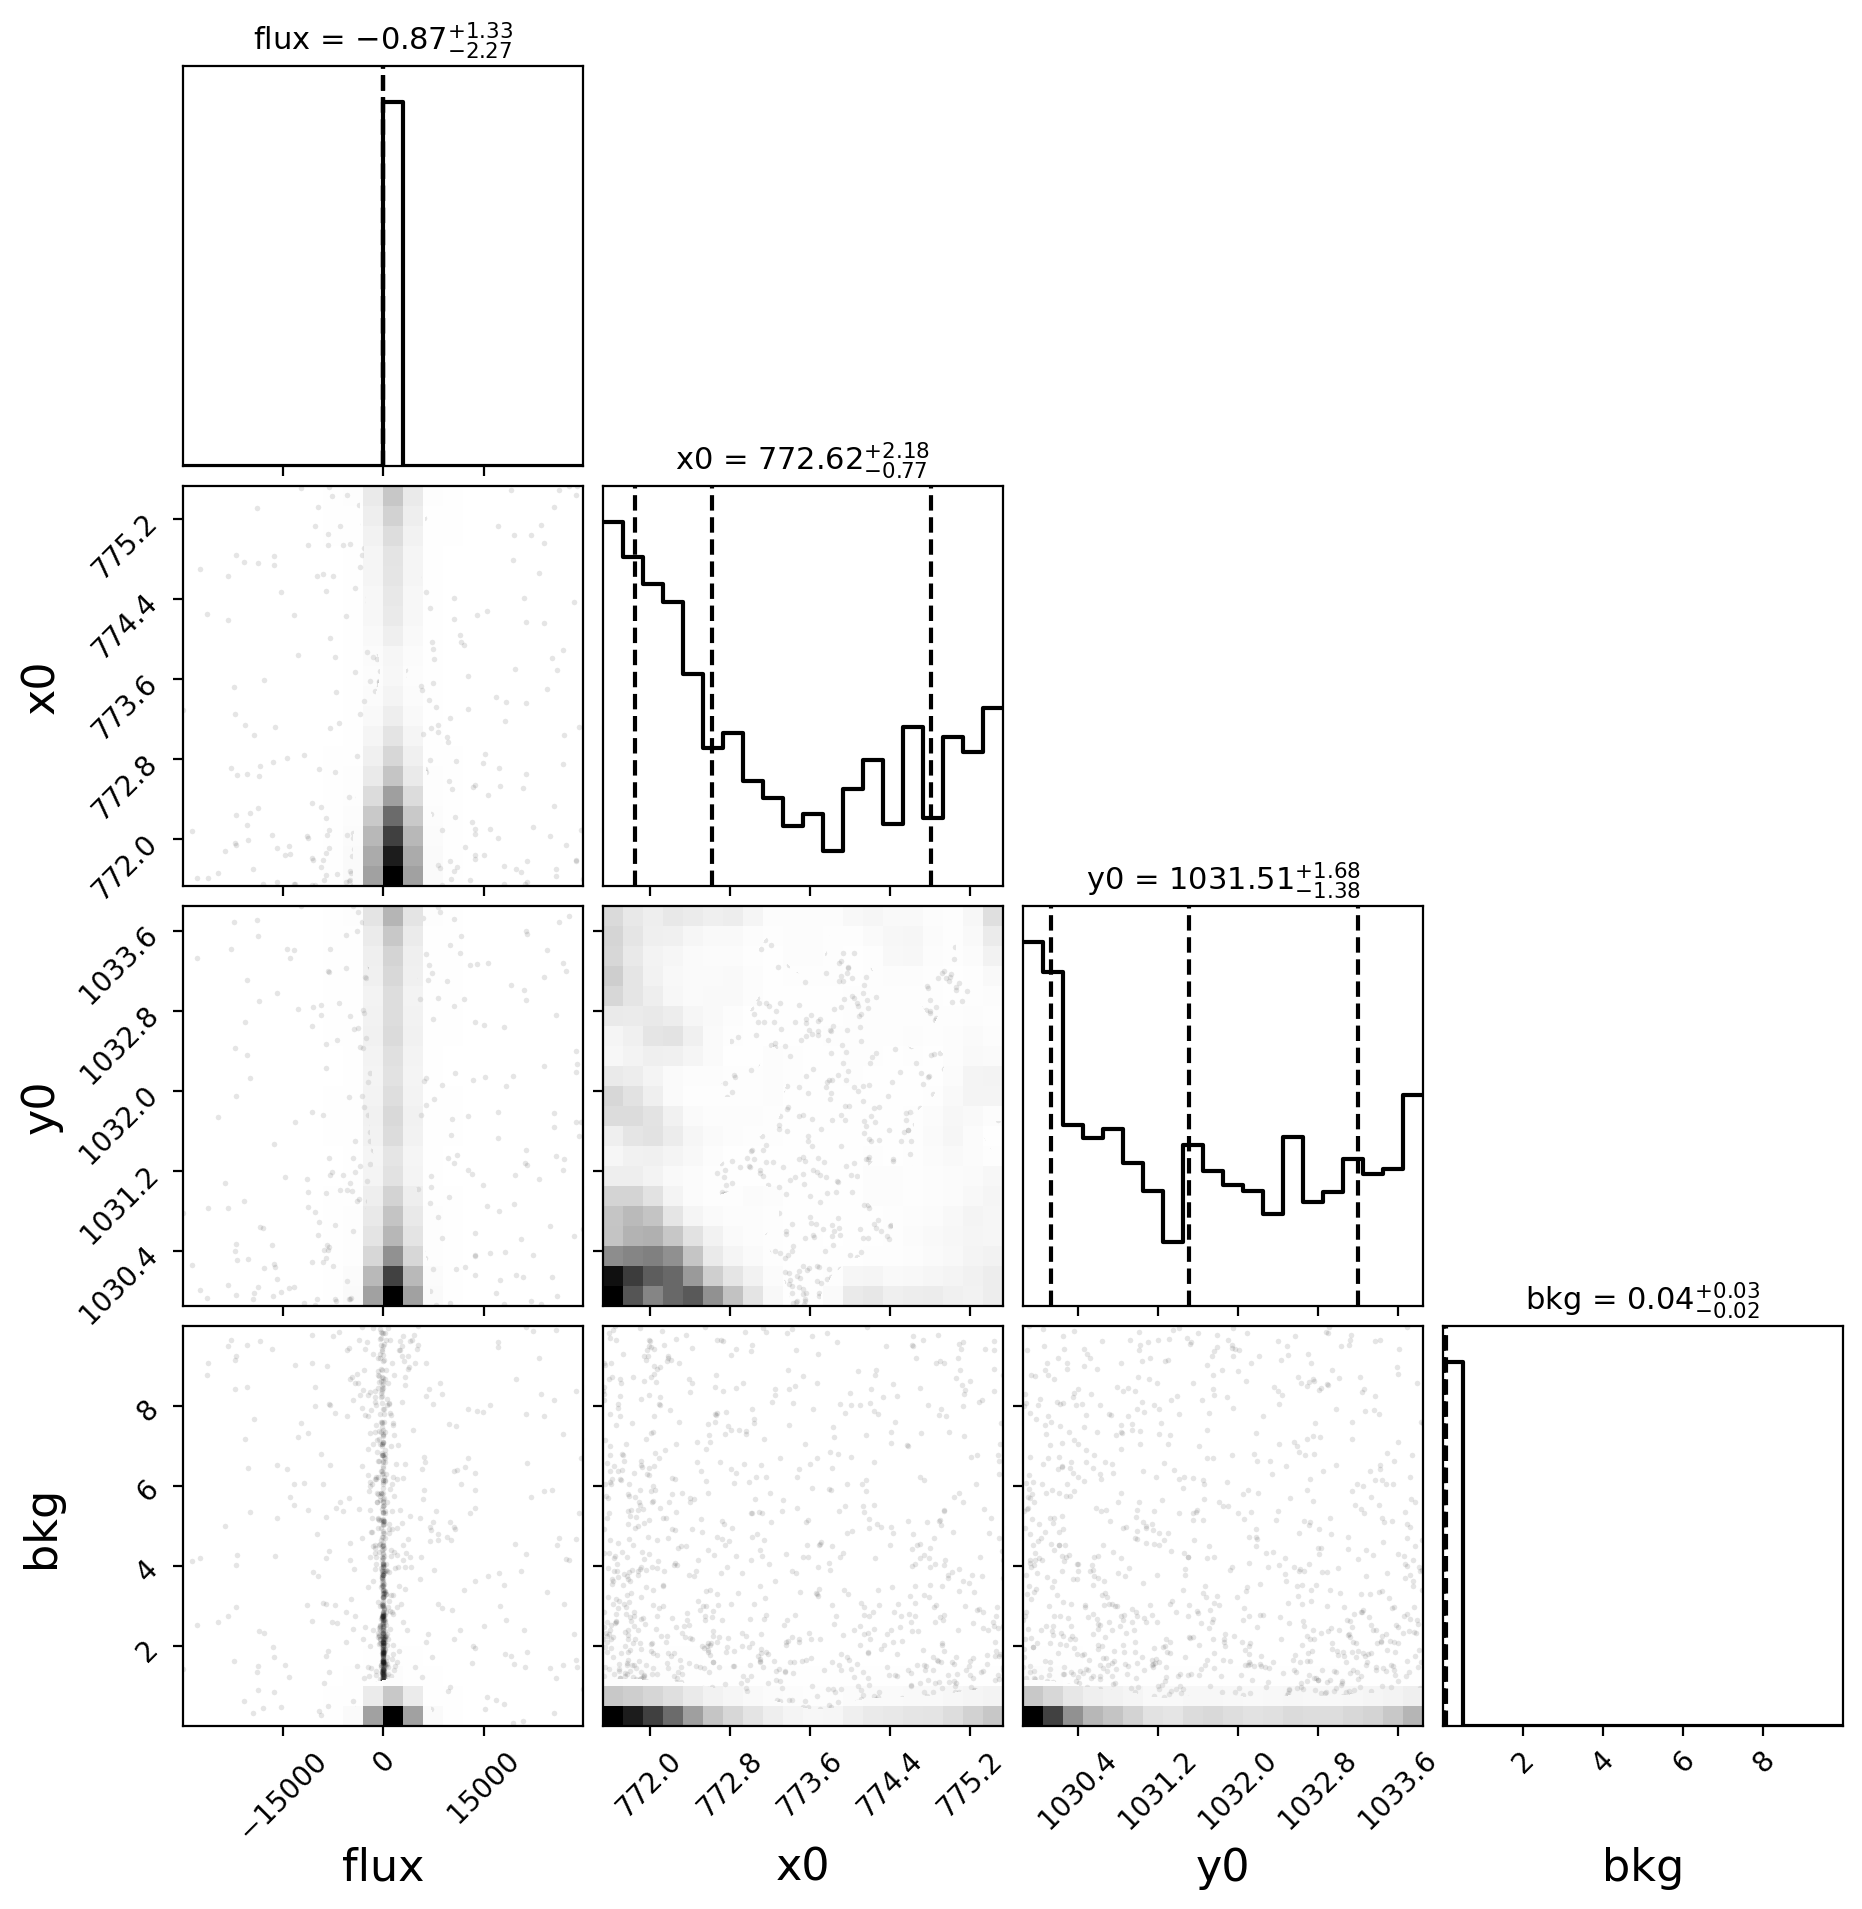

In [49]:
hst_drz_obs.plot_psf_posterior()
plt.show()

In [50]:
print(hst_drz_obs.psf_result.phot_cal_table)
#sys.exit()

        ra                ra_err        ... zpsys      exp      
----------------- --------------------- ... ----- --------------
53.38172615645605 2.222670895690726e-05 ...    ab F438W_drz.fits


In [51]:
hst_drz_obs.psf_result.phot_cal_table

ra,ra_err,dec,dec_err,x,x_err,y,y_err,mjd,flux,fluxerr,filter,zp,mag,magerr,zpsys,exp
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str5,float64,float64,float64,str2,str14
53.38172615645605,2.222670895690726e-05,-36.148673826571546,8.751732664791234e-06,773.0952168279161,1.2825680626364606,1031.6035884561338,1.2833073626549585,58684.87145776,-1.2945870041495986,2.565738603414105,F438W,24.82038034754739,nan,-2.1523405645015505,ab,F438W_drz.fits


In [52]:
hst_drz_obs.psf_result.phot_cal_table['mag','magerr']

mag,magerr
float64,float64
nan,-2.1523405645015505


In [53]:
hst_drz_obs.upper_limit(nsigma=5)

22.049924315415108

## F555W

In [54]:
indices = [i for i, x in enumerate(filter_arr) if x == 'F555W']
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_flcs = files[tmp]
input_flcs = input_flcs.tolist()
input_flcs

['HST/flc_lvl2/F555W_idxr09ztq_flc.fits',
 'HST/flc_lvl2/F555W_idxr09z0q_flc.fits',
 'HST/flc_lvl2/F555W_idxr09zdq_flc.fits']

In [55]:
hst_flc_obs = space_phot.observation2(input_flcs)
hst_drz_obs = space_phot.observation3('HST/drz_lvl3/hst_15654_09_wfc3_uvis_f555w_idxr09_drc.fits')
# hst_drz_obs = space_phot.observation3('./my_ad/f555w_17gax_{}_jhat_drc.fits'.format(year))


Cannot create flux_units from header...assuming electrons/s


/Users/sophiakressy/miniconda3/envs/ori_env/lib/python3.11/site-packages/space_phot/wfc3_photometry/psfs/PSFSTD_WFC3UV_F555W.fits
Using PSF file PSFSTD_WFC3UV_F555W.fits


INFO:drizzlepac.util:Setting up logfile :  astrodrizzle.log


Setting up logfile :  astrodrizzle.log


INFO:drizzlepac.astrodrizzle:AstroDrizzle log file: astrodrizzle.log


AstroDrizzle log file: astrodrizzle.log


...

INFO:drizzlepac.util:                  Total          2.8354 sec.


                  Total          2.8354 sec.


INFO:drizzlepac.util:


INFO:drizzlepac.imageObject:Removing intermediate files for /Users/sophiakressy/miniconda3/envs/ori_env/lib/python3.11/site-packages/space_phot/temp_656/F555W_idxr09z0q_flc.fits
INFO:drizzlepac.imageObject:Removing intermediate files for /Users/sophiakressy/miniconda3/envs/ori_env/lib/python3.11/site-packages/space_phot/temp_656/F555W_idxr09zdq_flc.fits
INFO:drizzlepac.imageObject:Removing intermediate files for /Users/sophiakressy/miniconda3/envs/ori_env/lib/python3.11/site-packages/space_phot/temp_656/F555W_idxr09ztq_flc.fits
INFO:drizzlepac.util:Trailer file written to:  astrodrizzle.log


Trailer file written to:  astrodrizzle.log


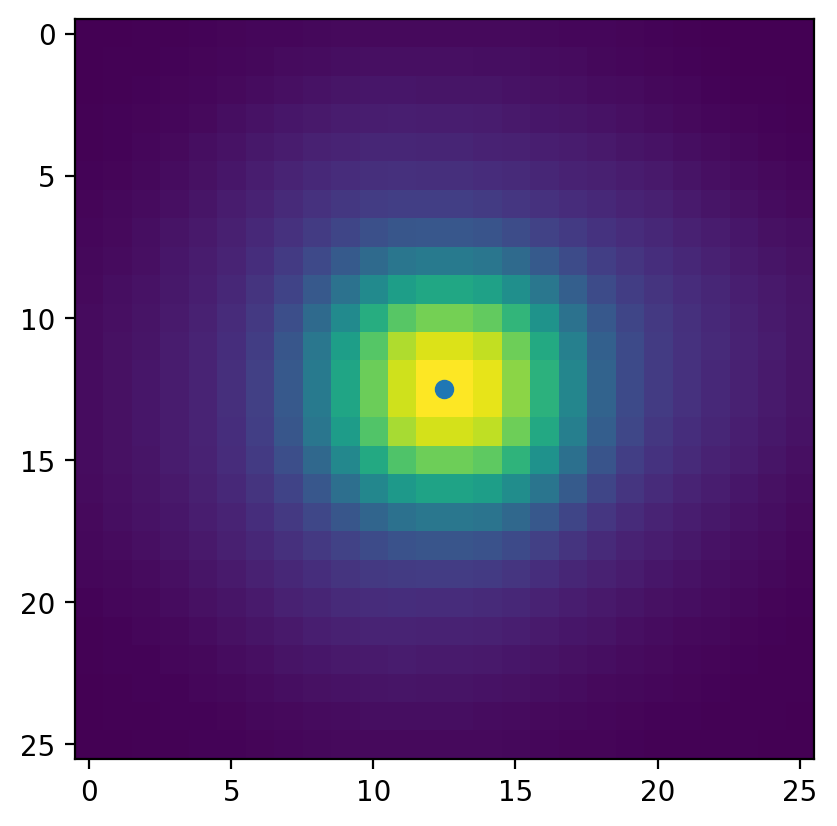

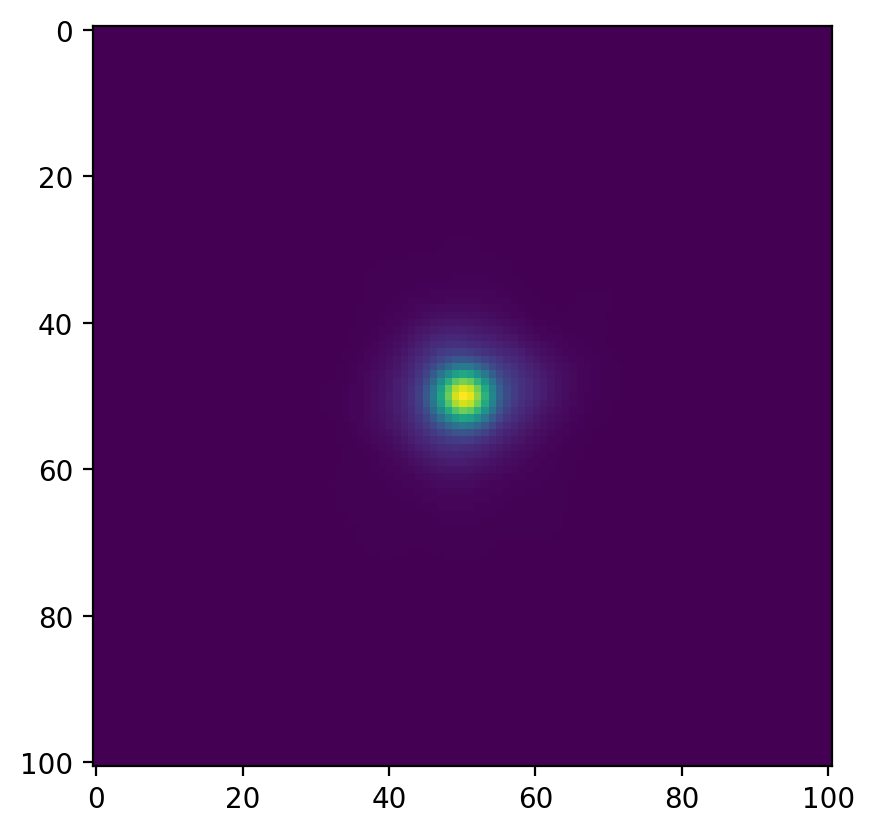

In [56]:
#psf_drz = pickle.load(open('psf_f555w_17gax.pkl','rb')) 
psf_drz = space_phot.get_hst3_psf(hst_flc_obs,hst_drz_obs,sn_location)#,num_psfs=4)
plt.imshow(psf_drz.data)
plt.show()

iter: 1178 | +100 | bound: 37 | nc: 1 | ncall: 7410 | eff(%): 17.483 | loglstar:   -inf < -0.025 <    inf | logz: -9.470 +/-  0.295 | dlogz:  0.001 >  0.109                                          

[1.56200535 1.25958663 1.31984839]
0.34273596287114916
[0.53535541 0.43170564 0.45235951]
Finished PSF psf_photometry with median residuals of -11.31%


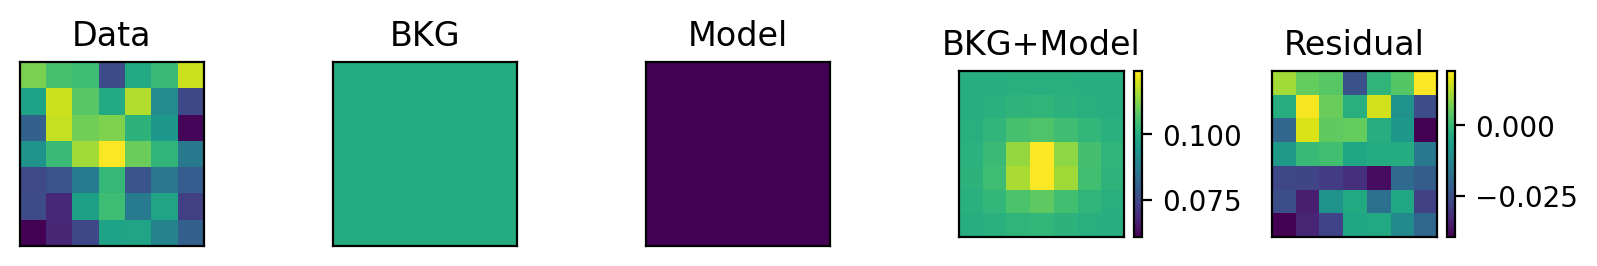

In [62]:
hst_drz_obs.psf_photometry(psf_drz,sn_location,bounds={'flux':[-30000,30000],
                        'centroid':[-2,2],
                        'bkg':[0,10]},
                        fit_width=7, 
                        background = 0.1, #(DS9), # 0.1 for 2023, #0.2 for 2019
                        # fit_bkg=True,
                        fit_centroid=True, 
                        fit_flux=True,psf_method='nest')

hst_drz_obs.plot_psf_fit()
plt.show()

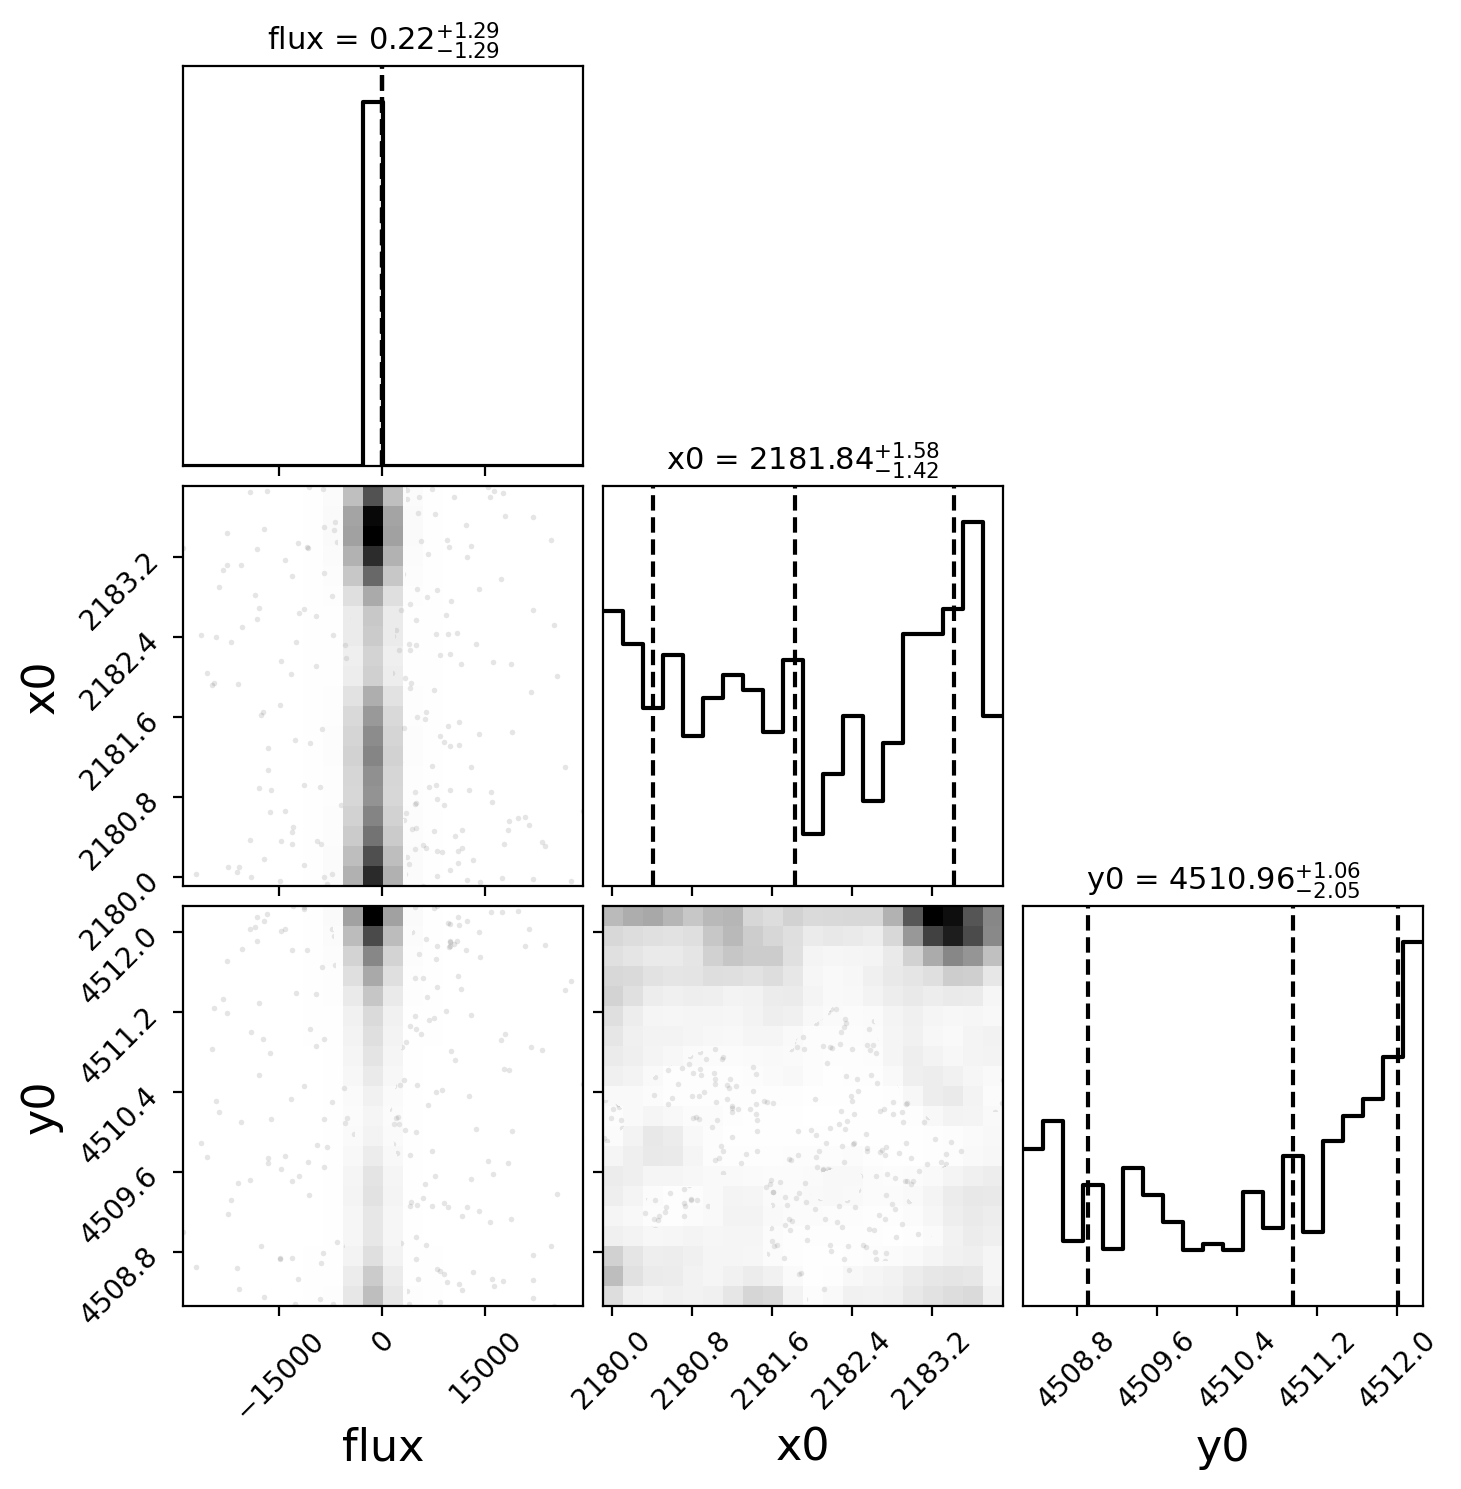

       ra       ...                     exp                     
--------------- ... --------------------------------------------
53.381728270209 ... hst_15654_09_wfc3_uvis_f555w_idxr09_drc.fits


In [63]:
hst_drz_obs.plot_psf_posterior()
plt.show()

print(hst_drz_obs.psf_result.phot_cal_table)
#sys.exit()

In [64]:
hst_drz_obs.psf_result.phot_cal_table

ra,ra_err,dec,dec_err,x,x_err,y,y_err,mjd,flux,fluxerr,filter,zp,mag,magerr,zpsys,exp
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str5,float64,float64,float64,str2,str44
53.381728270209,1.7984531460513153e-05,-36.14867243004841,1.3865959388681404e-05,2181.9427685081932,1.2595866292557603,4510.602939884876,1.3198483870646656,58684.89383035,0.2614439622831367,1.562005347022275,F555W,25.789908279183724,27.246461737181225,6.488341868951263,ab,hst_15654_09_wfc3_uvis_f555w_idxr09_drc.fits


In [65]:
hst_drz_obs.psf_result.phot_cal_table['mag','magerr']

mag,magerr
float64,float64
27.246461737181225,6.488341868951263


In [66]:
hst_drz_obs.upper_limit(nsigma=5)

23.558276977815865

## F814W

In [57]:
indices = [i for i, x in enumerate(filter_arr) if x == 'F814W']
filters = np.array(filter_arr)
files = np.array(file_arr)

In [58]:
tmp = np.array(indices)
filters[tmp]
input_flcs = files[tmp]
input_flcs = input_flcs.tolist()
input_flcs

['HST/flc_lvl2/F814W_idxr09z2q_flc.fits',
 'HST/flc_lvl2/F814W_idxr09yqq_flc.fits',
 'HST/flc_lvl2/F814W_idxr09zfq_flc.fits']

In [59]:
hst_flc_obs = space_phot.observation2(input_flcs)
hst_drz_obs = space_phot.observation3('HST/drz_lvl3/F814W_drz.fits')
# hst_drz_obs = space_phot.observation3('./my_ad/f555w_17gax_{}_jhat_drc.fits'.format(year))

Cannot create flux_units from header...assuming electrons/s


/Users/sophiakressy/miniconda3/envs/ori_env/lib/python3.11/site-packages/space_phot/wfc3_photometry/psfs/PSFSTD_WFC3UV_F814W.fits
Using PSF file PSFSTD_WFC3UV_F814W.fits


INFO:drizzlepac.util:Setting up logfile :  astrodrizzle.log


Setting up logfile :  astrodrizzle.log


INFO:drizzlepac.astrodrizzle:AstroDrizzle log file: astrodrizzle.log


AstroDrizzle log file: astrodrizzle.log


...

INFO:drizzlepac.util:                  Total          2.7089 sec.


                  Total          2.7089 sec.


INFO:drizzlepac.util:


INFO:drizzlepac.imageObject:Removing intermediate files for /Users/sophiakressy/miniconda3/envs/ori_env/lib/python3.11/site-packages/space_phot/temp_962/F814W_idxr09yqq_flc.fits
INFO:drizzlepac.imageObject:Removing intermediate files for /Users/sophiakressy/miniconda3/envs/ori_env/lib/python3.11/site-packages/space_phot/temp_962/F814W_idxr09z2q_flc.fits
INFO:drizzlepac.imageObject:Removing intermediate files for /Users/sophiakressy/miniconda3/envs/ori_env/lib/python3.11/site-packages/space_phot/temp_962/F814W_idxr09zfq_flc.fits
INFO:drizzlepac.util:Trailer file written to:  astrodrizzle.log


Trailer file written to:  astrodrizzle.log


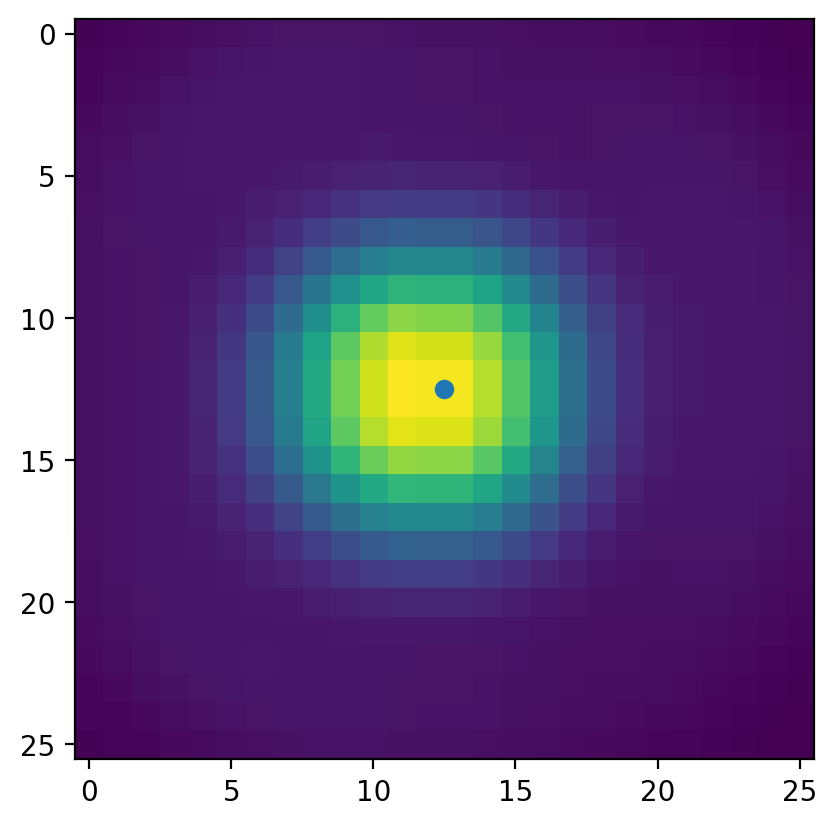

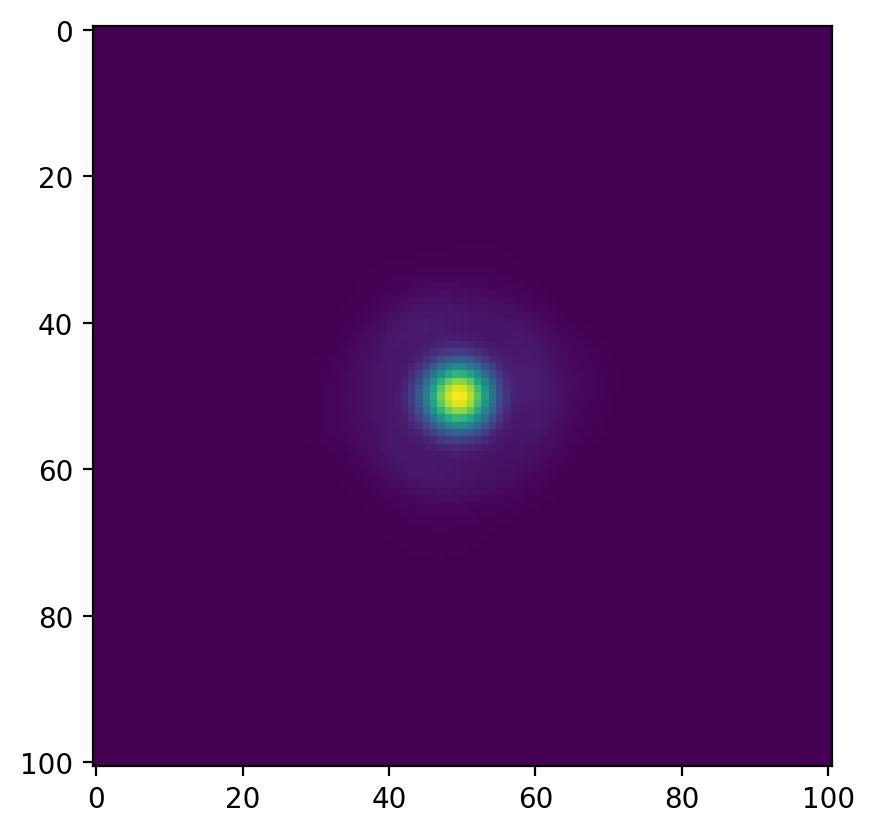

In [60]:
#psf_drz = pickle.load(open('psf_f555w_17gax.pkl','rb')) 
psf_drz = space_phot.get_hst3_psf(hst_flc_obs,hst_drz_obs,sn_location)#,num_psfs=4)
plt.imshow(psf_drz.data)
plt.show()

iter: 1497 | +100 | bound: 76 | nc: 1 | ncall: 12242 | eff(%): 13.153 | loglstar:   -inf < -0.028 <    inf | logz: -12.652 +/-  0.340 | dlogz:  0.001 >  0.109                                        

[2.31149881 1.31034595 1.35023954 0.03649812]
0.34652321555320015
[0.800988   0.45406529 0.46788935 0.01264745]
Finished PSF psf_photometry with median residuals of 577.13%


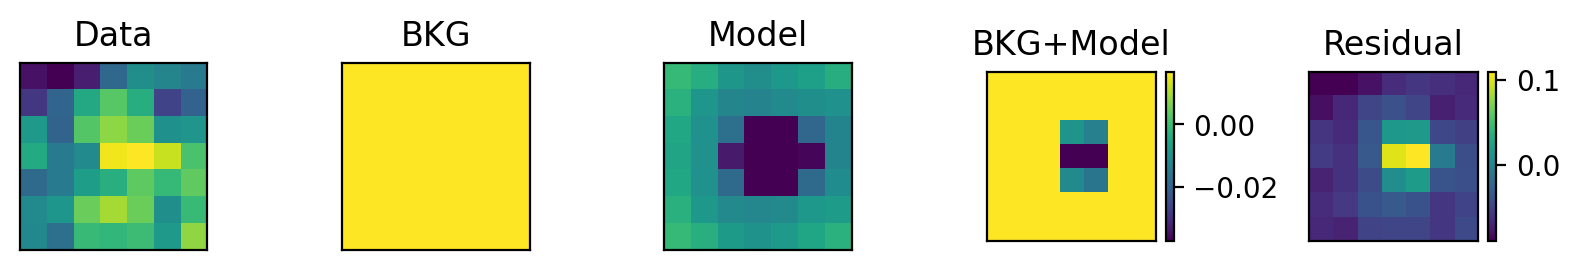

In [61]:
hst_drz_obs.psf_photometry(psf_drz,sn_location,bounds={'flux':[-30000,30000],
                        'centroid':[-2,2],
                        'bkg':[0,1]},
                        fit_width=7, 
                        background = 0.01, #(DS9), # 0.1 for 2023, #0.2 for 2019
                        fit_bkg=True,
                        fit_centroid=True, 
                        fit_flux=True,psf_method='nest')

hst_drz_obs.plot_psf_fit()
plt.show()

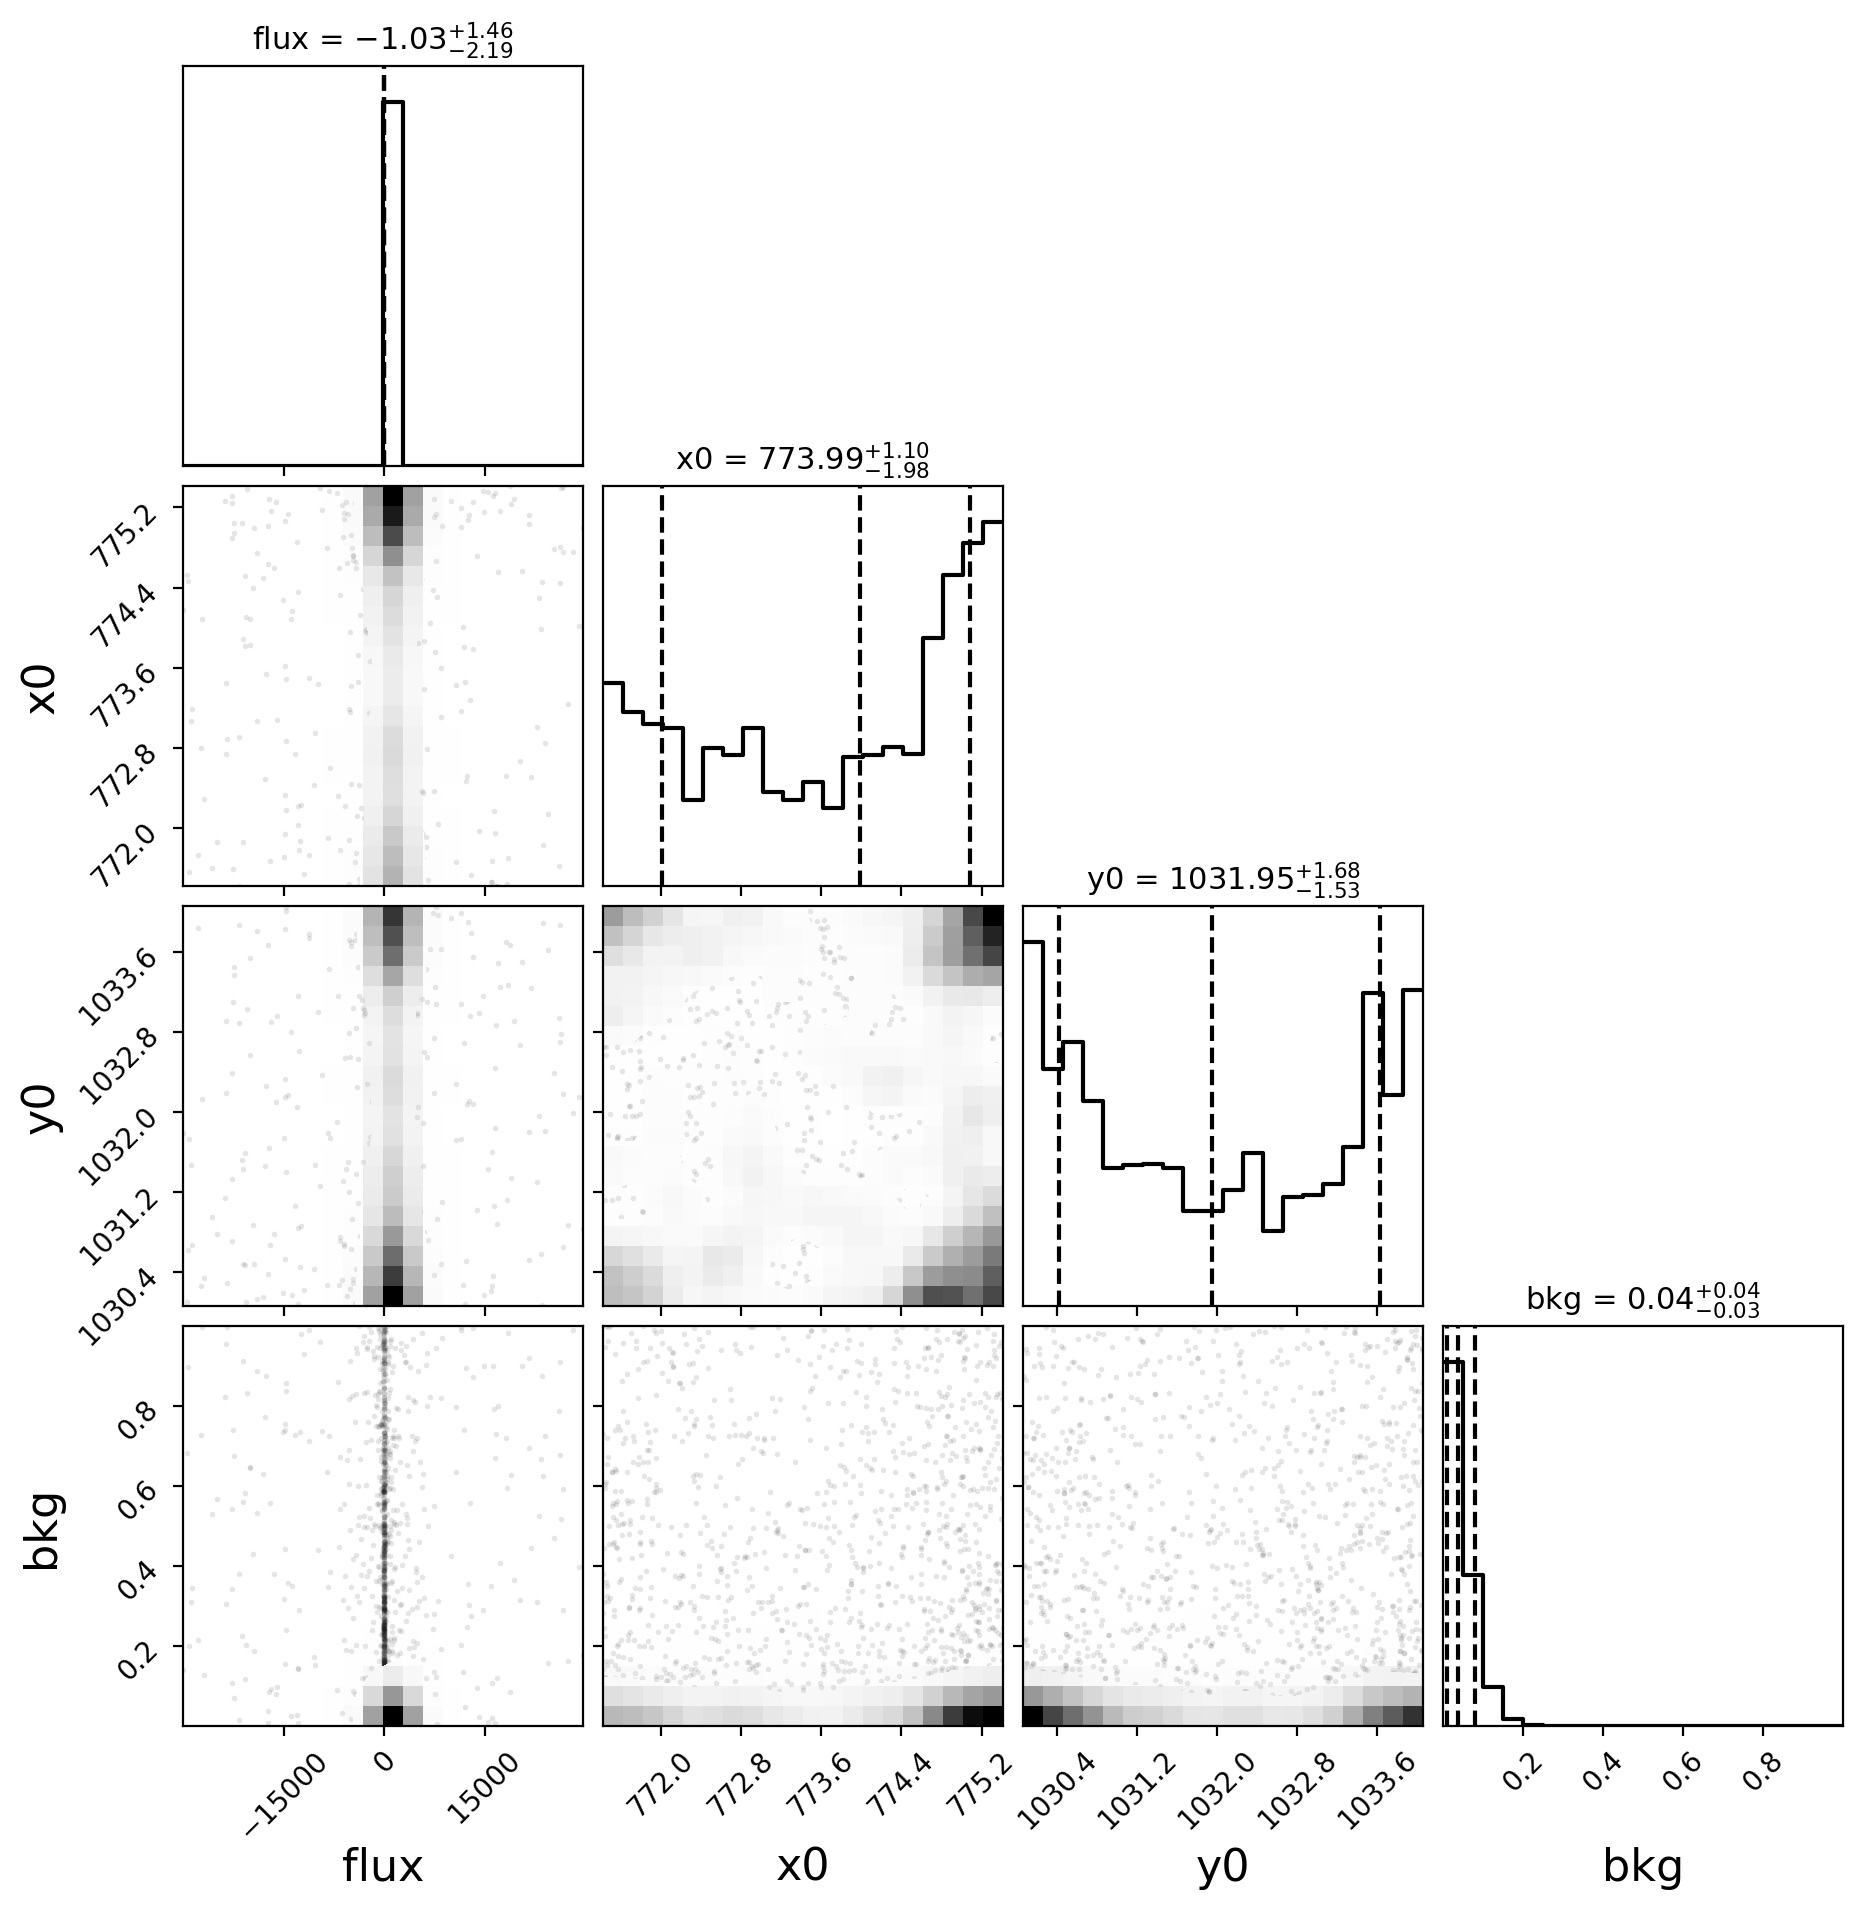

In [62]:
hst_drz_obs.plot_psf_posterior()
plt.show()

In [63]:
print(hst_drz_obs.psf_result.phot_cal_table)
#sys.exit()

       ra               ra_err         ... zpsys      exp      
--------------- ---------------------- ... ----- --------------
53.381736345917 2.2881952908448966e-05 ...    ab F814W_drz.fits


In [64]:
hst_drz_obs.psf_result.phot_cal_table

ra,ra_err,dec,dec_err,x,x_err,y,y_err,mjd,flux,fluxerr,filter,zp,mag,magerr,zpsys,exp
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str5,float64,float64,float64,str2,str14
53.381736345917,2.2881952908448966e-05,-36.14867435388551,9.348497862049499e-06,773.7024840831035,1.3103459531951223,1032.002384518913,1.350239539006396,58684.86655035,-1.2698468277700619,2.3114988117827697,F814W,25.11645498570816,nan,-1.9768429189245804,ab,F814W_drz.fits


In [65]:
hst_drz_obs.psf_result.phot_cal_table['mag','magerr']

mag,magerr
float64,float64
nan,-1.9768429189245804


In [66]:
hst_drz_obs.upper_limit(nsigma=5)

22.459295788551312

## Make non-existent SED with HST non-detections

<!-- F275W -- 21.787767870024453
F336W -- 22.588968792329382
F438W -- 22.049924315415108
F555W -- 23.558276977815865
F814W -- 22.4003715472723 -->

In [ ]:
# filter_list = ['F275W', 'F336W', 'F438W', 'F555W', 'F814W']
# mags_list   = [21.787767870024453, 22.588968792329382, 22.049924315415108, 23.558276977815865, 22.4003715472723]
# flux_list   = []

# for ifilter in range(len(filter_list)):
#     flux_jy = 10**(-0.4 * (mags_list[ifilter] + 48.6)) * 1e23
#     flux_list.append(flux_jy)


Text(0, 0.5, 'Flux (Jy)')

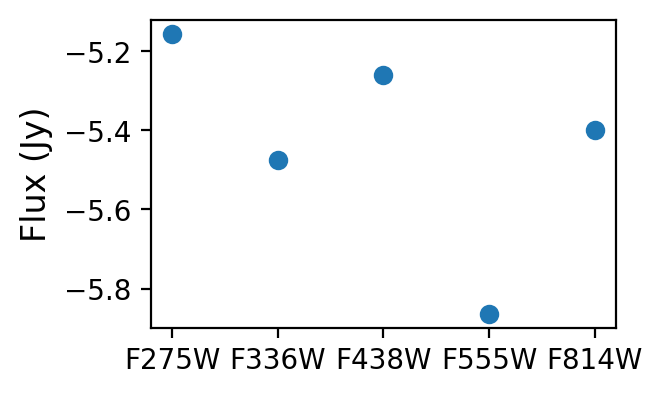

In [ ]:
# plt.figure(figsize=(3,2))
# plt.plot(filter_list, np.log10(flux_list), marker='o', linestyle='none')
# plt.ylabel('Flux (Jy)', fontsize = 12)

Text(0, 0.5, 'Mag (Abs)')

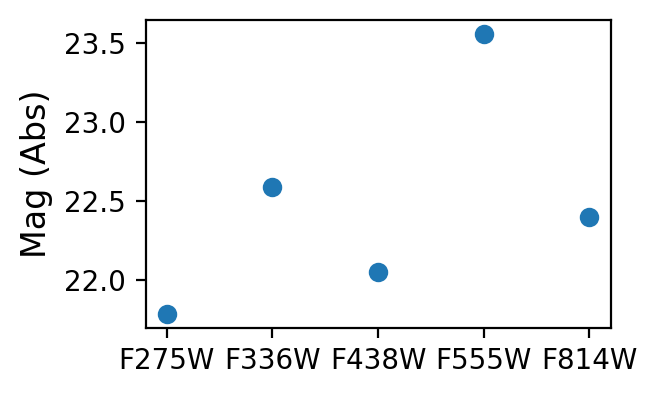

In [ ]:
# plt.figure(figsize=(3,2))
# plt.plot(filter_list, mags_list, marker='o', linestyle='none')
# plt.ylabel('Mag (Abs)', fontsize = 12)